# SBND PosRecoCVN Data Reader

Comprehensive notebook to read CNN position reconstruction results from PosRecoCVNProducer output.
Supports both **TTree** (simple analysis) and **PixelMapVars** (detailed analysis) formats.

## Output Format Overview
The PosRecoCVNProducer creates **two complementary data structures**:
1. **`inference_tree`**: Simple TTree with flat variables (recommended for quick analysis)
2. **`PixelMapVars`**: Complex object with PE images, matrices, and detailed physics data

In [158]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

### local

In [159]:
# File path - update this to your pixelmap_variables.root location
file_path = "/exp/sbnd/app/users/svidales/larsoft_develop/run_try/2000/ttree_analysis_PosRecoCVNProd-20251002T153139.root"  # Updated for complete data

print(f"Reading file: {file_path}")
print(f"File exists: {Path(file_path).exists()}")
if Path(file_path).exists():
    print(f"File size: {Path(file_path).stat().st_size / 1024:.1f} KB")
else:
    print("❌ File not found! Make sure you've run the job with both TFileService and RootOutput enabled.")

Reading file: /exp/sbnd/app/users/svidales/larsoft_develop/run_try/2000/ttree_analysis_PosRecoCVNProd-20251002T153139.root
File exists: True
File size: 14.8 KB


### grid jobs

In [160]:
# File path - update this to your pixelmap_variables.root location
file_path = "/exp/sbnd/data/users/svidales/AI_nuvT_project_support/tools/8k_test_v0912.root"  # Updated for complete data

print(f"Reading file: {file_path}")
print(f"File exists: {Path(file_path).exists()}")
if Path(file_path).exists():
    print(f"File size: {Path(file_path).stat().st_size / 1024:.1f} KB")
else:
    print("❌ File not found! Make sure you've run the job with both TFileService and RootOutput enabled.")

Reading file: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/tools/8k_test_v0912.root
File exists: False
❌ File not found! Make sure you've run the job with both TFileService and RootOutput enabled.


## Only TFileService output (ttree_analysis.root)

Simple, fast analysis using the flat TTree structure. Each row = one event.

In [161]:
# Open file and check for TTree
file = uproot.open(file_path)
print("ROOT file contents:")
for key in file.keys():
    print(f"  - {key}")

# Check subdirectories for TTree (often stored in TFileService subdirectories)
print("\nExploring subdirectories for TTrees:")
subdirs_to_check = []
for key in file.keys():
    try:
        obj = file[key]
        if hasattr(obj, 'keys'):  # It's a directory
            subdirs_to_check.append(key)
            print(f"\n📁 {key} contents:")
            subkeys = obj.keys()
            for subkey in subkeys:
                print(f"    - {subkey}")
                if 'tree' in subkey.lower() or 'inference' in subkey.lower():
                    print(f"      🌲 Found potential tree: {subkey}")
    except:
        continue

# Check if new TTree format exists (check both root level and subdirectories)
has_inference_tree = 'inference_tree' in file.keys()
inference_tree_path = None

if not has_inference_tree:
    # Check in subdirectories
    for subdir in subdirs_to_check:
        try:
            subdir_obj = file[subdir]
            if hasattr(subdir_obj, 'keys'):
                subkeys = subdir_obj.keys()
                for subkey in subkeys:
                    if 'inference_tree' in subkey.lower():
                        has_inference_tree = True
                        inference_tree_path = f"{subdir}/{subkey}"
                        print(f"\n✅ Found TTree at: {inference_tree_path}")
                        break
                if has_inference_tree:
                    break
        except:
            continue

print(f"\nNew TTree format available: {has_inference_tree}")
if inference_tree_path:
    print(f"TTree location: {inference_tree_path}")

# Also check for art framework data products (Events tree)
print(f"\nChecking for art framework data products...")
has_events = 'Events' in file.keys() or any('events' in key.lower() for key in file.keys())
print(f"Events tree available: {has_events}")

# Check if the PixelMapVars product exists in the file
has_pixelmap_vars = False
for key in file.keys():
    if 'PixelMapVars' in key or 'opanatree' in key:
        has_pixelmap_vars = True
        print(f"Found PixelMapVars-related key: {key}")

print(f"PixelMapVars data available: {has_pixelmap_vars}")

# Load the TTree if found
tree = None
if has_inference_tree:
    if inference_tree_path:
        tree = file[inference_tree_path]
    else:
        tree = file['inference_tree']  # fallback for root level
    print(f"\n✅ TTree loaded successfully with {tree.num_entries} entries")

FileNotFoundError: [Errno 2] No such file or directory: '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/tools/8k_test_v0912.root'

In [ ]:
if has_inference_tree:
    
    # Read all branches into arrays
    data = tree.arrays(library='pd')  # Read as pandas DataFrame
    
    # Filter events that passed filters
    passed_events = data[data['passed_filters'] == True]
    print(f"\n=== Filter Summary ====")
    print(f"Total events: {len(data)}")
    print(f"Passed filters: {len(passed_events)}")
    print(f"Success rate: {100*len(passed_events)/len(data):.1f}%")
    
    # Show events table - only passed events, and all events if <50
    if len(passed_events) < 50:
        print(f"\n=== All Events That Passed Filters ({len(passed_events)} events) ====")
        display(passed_events.round(2))
    else:
        print(f"\n=== First 10 Events That Passed Filters ====")
        display(passed_events.head(10).round(2))
    
    if len(passed_events) > 0:
        print(f"\n=== Performance Summary ({len(passed_events)} events) ====")
        
        # Calculate performance metrics for events that have predictions
        valid_predictions = passed_events[passed_events['error_3d'] != -999.0]
        
        if len(valid_predictions) > 0:
            coords = ['x', 'y', 'z']
            for coord in coords:
                diff_col = f'diff_{coord}'
                if diff_col in valid_predictions.columns:
                    diff_values = valid_predictions[diff_col].values
                    print(f"* {coord.upper()} coordinate:")
                    print(f"  - Mean difference (Bias): {np.mean(diff_values):6.2f} cm")
                    print(f"  - Std difference:         {np.std(diff_values):6.2f} cm")
                    print(f"  - RMSE:                   {np.sqrt(np.mean(diff_values**2)):6.2f} cm")
                    print(f"  - MAE:                    {np.mean(np.abs(diff_values)):6.2f} cm")
            
        else:
            print("No events with valid predictions found.")
    
else:
    print("❌ TTree format not found. File may be from older version without TTree support.")
    print("Checking if this might be due to old fcl outputCommands...")
    print("Make sure fcl file includes: 'keep *_TFileService_*_*'")


=== Filter Summary ====
Total events: 15
Passed filters: 6
Success rate: 40.0%

=== All Events That Passed Filters (6 events) ====


,run,subrun,event,passed_filters,pred_x,pred_y,pred_z,true_x,true_y,true_z,diff_x,diff_y,diff_z,error_3d,nuv_t,nuv_z,deposited_energy
0,136,76,7,True,158.61,-190.50,386.69,159.31,-196.87,389.67,-0.70,6.37,-2.98,7.07,1381.14,383.73,108.05
5,136,76,38,True,53.65,-94.36,426.66,46.45,-88.79,424.21,7.20,-5.57,2.45,9.43,1288.12,337.20,1493.22
8,136,76,45,True,48.77,173.77,25.35,60.49,170.62,36.63,-11.72,3.15,-11.28,16.57,1540.64,-60.74,264.55
12,136,76,94,True,59.27,59.22,46.42,64.66,51.97,49.87,-5.39,7.25,-3.46,9.67,1276.11,-2.02,422.52
13,136,76,98,True,106.54,-175.45,134.40,108.06,-174.61,127.00,-1.52,-0.84,7.40,7.60,618.29,117.91,183.93
14,136,76,100,True,133.19,-82.65,56.33,129.13,-90.30,64.05,4.06,7.65,-7.71,11.60,1179.78,-20.31,363.82



=== Performance Summary (6 events) ====
* X coordinate:
  - Mean difference (Bias):  -1.34 cm
  - Std difference:           6.15 cm
  - RMSE:                     6.29 cm
  - MAE:                      5.10 cm
* Y coordinate:
  - Mean difference (Bias):   3.00 cm
  - Std difference:           4.82 cm
  - RMSE:                     5.68 cm
  - MAE:                      5.14 cm
* Z coordinate:
  - Mean difference (Bias):  -2.60 cm
  - Std difference:           6.16 cm
  - RMSE:                     6.69 cm
  - MAE:                      5.88 cm


In [ ]:
if has_inference_tree:
    
    # Read all branches into arrays
    data = tree.arrays(library='pd')  # Read as pandas DataFrame
    
    # Filter events that passed filters
    passed_events = data[data['passed_filters'] == True]
    print(f"\n=== Filter Summary ====")
    print(f"Total events: {len(data)}")
    print(f"Passed filters: {len(passed_events)}")
    print(f"Success rate: {100*len(passed_events)/len(data):.1f}%")
    
    # Show events table - only passed events, and all events if <50
    if len(passed_events) < 50:
        print(f"\n=== All Events That Passed Filters ({len(passed_events)} events) ====")
        display(passed_events.round(2))
    else:
        print(f"\n=== First 10 Events That Passed Filters ====")
        display(passed_events.head(10).round(2))
    
    if len(passed_events) > 0:
        print(f"\n=== Performance Summary ({len(passed_events)} events) ====")
        
        
        if len(passed_events) > 0:
            coords = ['x', 'y', 'z']
            for coord in coords:
                diff_col = f'diff_{coord}'
                if diff_col in passed_events.columns:
                    diff_values = passed_events[diff_col].values
                    print(f"* {coord.upper()} coordinate:")
                    print(f"  - Mean difference (Bias): {np.mean(diff_values):6.2f} cm")
                    print(f"  - Std difference:         {np.std(diff_values):6.2f} cm")
                    print(f"  - RMSE:                   {np.sqrt(np.mean(diff_values**2)):6.2f} cm")
                    print(f"  - MAE:                    {np.mean(np.abs(diff_values)):6.2f} cm")
            
        else:
            print("No events with valid predictions found.")
    
else:
    print("❌ TTree format not found. File may be from older version without TTree support.")
    print("Checking if this might be due to old fcl outputCommands...")
    print("Make sure fcl file includes: 'keep *_TFileService_*_*'")


=== Filter Summary ====
Total events: 22
Passed filters: 12
Success rate: 54.5%

=== All Events That Passed Filters (12 events) ====


,run,subrun,event,passed_filters,pred_x,pred_y,pred_z,true_x,true_y,true_z,diff_x,diff_y,diff_z,error_3d,nuv_t,nuv_z,deposited_energy
1,358,91,11,True,143.31,178.24,63.19,146.01,171.63,48.09,-2.70,6.61,15.10,16.71,1276.19,24.84,327.96
5,358,91,31,True,122.68,179.26,448.78,115.67,168.18,438.46,7.01,11.08,10.31,16.68,1006.63,425.86,316.22
6,358,91,33,True,146.95,-54.02,73.90,138.32,-55.59,76.14,8.63,1.57,-2.24,9.06,1392.16,54.41,418.76
8,358,91,43,True,34.00,-188.86,487.05,8.04,-187.94,499.54,25.96,-0.92,-12.49,28.82,422.95,487.02,88.58
9,358,91,46,True,189.62,-190.38,324.12,194.59,-198.01,312.41,-4.98,7.63,11.71,14.83,1233.94,310.16,106.02
10,358,91,48,True,194.48,-191.30,382.28,193.66,-181.48,373.37,0.83,-9.82,8.91,13.28,455.48,380.68,154.51
11,358,91,50,True,86.04,-181.50,158.10,95.05,-179.71,147.65,-9.01,-1.78,10.45,13.91,1395.69,139.62,99.89
14,358,91,67,True,159.38,-82.24,112.74,163.12,-90.48,123.37,-3.74,8.24,-10.62,13.96,859.96,-21.98,575.83
15,358,91,69,True,142.48,72.51,225.47,147.86,78.58,210.29,-5.38,-6.08,15.18,17.22,502.54,179.53,630.18
17,358,91,82,True,108.22,-30.78,35.09,108.34,-33.66,28.30,-0.12,2.88,6.79,7.38,653.98,25.51,415.64



=== Performance Summary (12 events) ====
* X coordinate:
  - Mean difference (Bias):   2.55 cm
  - Std difference:           9.96 cm
  - RMSE:                    10.28 cm
  - MAE:                      7.42 cm
* Y coordinate:
  - Mean difference (Bias):   0.34 cm
  - Std difference:           6.95 cm
  - RMSE:                     6.96 cm
  - MAE:                      6.00 cm
* Z coordinate:
  - Mean difference (Bias):   2.24 cm
  - Std difference:          11.52 cm
  - RMSE:                    11.73 cm
  - MAE:                     10.84 cm


### TTree Visualization

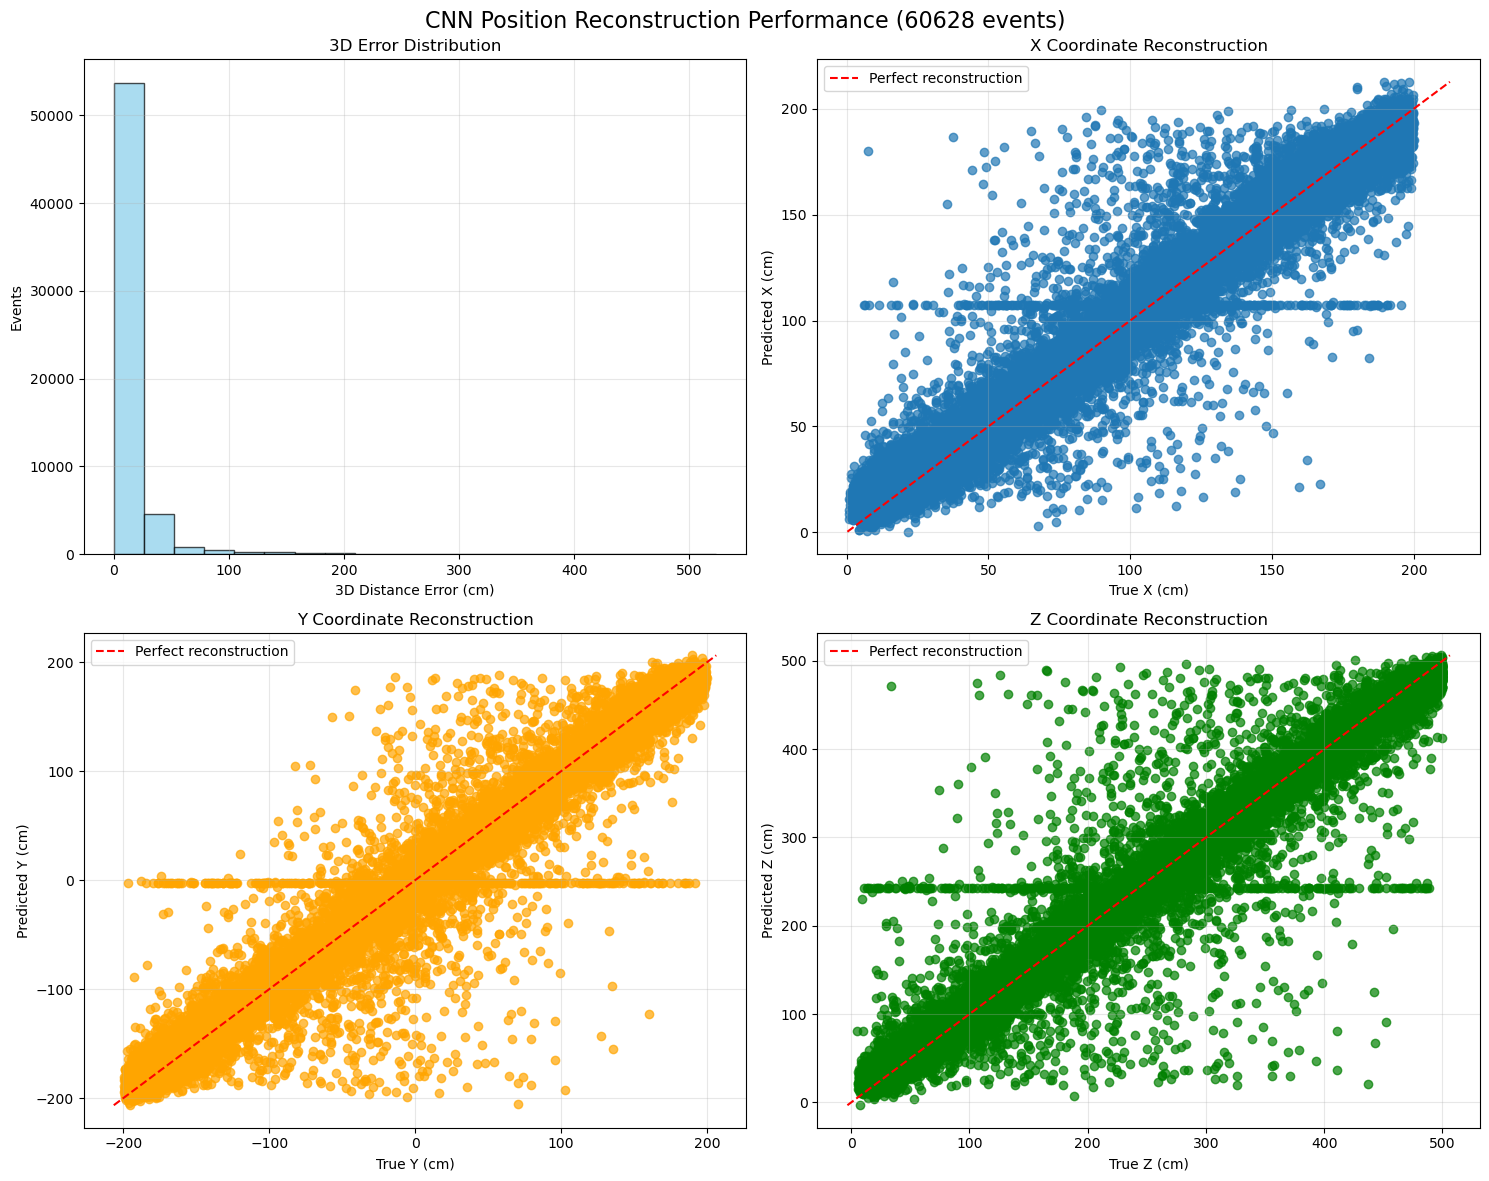

In [ ]:
if has_inference_tree and len(passed_events) > 0:
    valid_predictions = passed_events[passed_events['error_3d'] != -999.0]
    
    if len(valid_predictions) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle(f'CNN Position Reconstruction Performance ({len(valid_predictions)} events)', fontsize=16)
        
        # 3D error distribution
        axes[0,0].hist(valid_predictions['error_3d'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0,0].set_xlabel('3D Distance Error (cm)')
        axes[0,0].set_ylabel('Events')
        axes[0,0].set_title('3D Error Distribution')
        axes[0,0].grid(True, alpha=0.3)
        
        # X coordinate comparison
        axes[0,1].scatter(valid_predictions['true_x'], valid_predictions['pred_x'], alpha=0.7)
        min_x, max_x = min(valid_predictions['true_x'].min(), valid_predictions['pred_x'].min()), max(valid_predictions['true_x'].max(), valid_predictions['pred_x'].max())
        axes[0,1].plot([min_x, max_x], [min_x, max_x], 'r--', label='Perfect reconstruction')
        axes[0,1].set_xlabel('True X (cm)')
        axes[0,1].set_ylabel('Predicted X (cm)')
        axes[0,1].set_title('X Coordinate Reconstruction')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # Y coordinate comparison
        axes[1,0].scatter(valid_predictions['true_y'], valid_predictions['pred_y'], alpha=0.7, color='orange')
        min_y, max_y = min(valid_predictions['true_y'].min(), valid_predictions['pred_y'].min()), max(valid_predictions['true_y'].max(), valid_predictions['pred_y'].max())
        axes[1,0].plot([min_y, max_y], [min_y, max_y], 'r--', label='Perfect reconstruction')
        axes[1,0].set_xlabel('True Y (cm)')
        axes[1,0].set_ylabel('Predicted Y (cm)')
        axes[1,0].set_title('Y Coordinate Reconstruction')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Z coordinate comparison
        axes[1,1].scatter(valid_predictions['true_z'], valid_predictions['pred_z'], alpha=0.7, color='green')
        min_z, max_z = min(valid_predictions['true_z'].min(), valid_predictions['pred_z'].min()), max(valid_predictions['true_z'].max(), valid_predictions['pred_z'].max())
        axes[1,1].plot([min_z, max_z], [min_z, max_z], 'r--', label='Perfect reconstruction')
        axes[1,1].set_xlabel('True Z (cm)')
        axes[1,1].set_ylabel('Predicted Z (cm)')
        axes[1,1].set_title('Z Coordinate Reconstruction')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

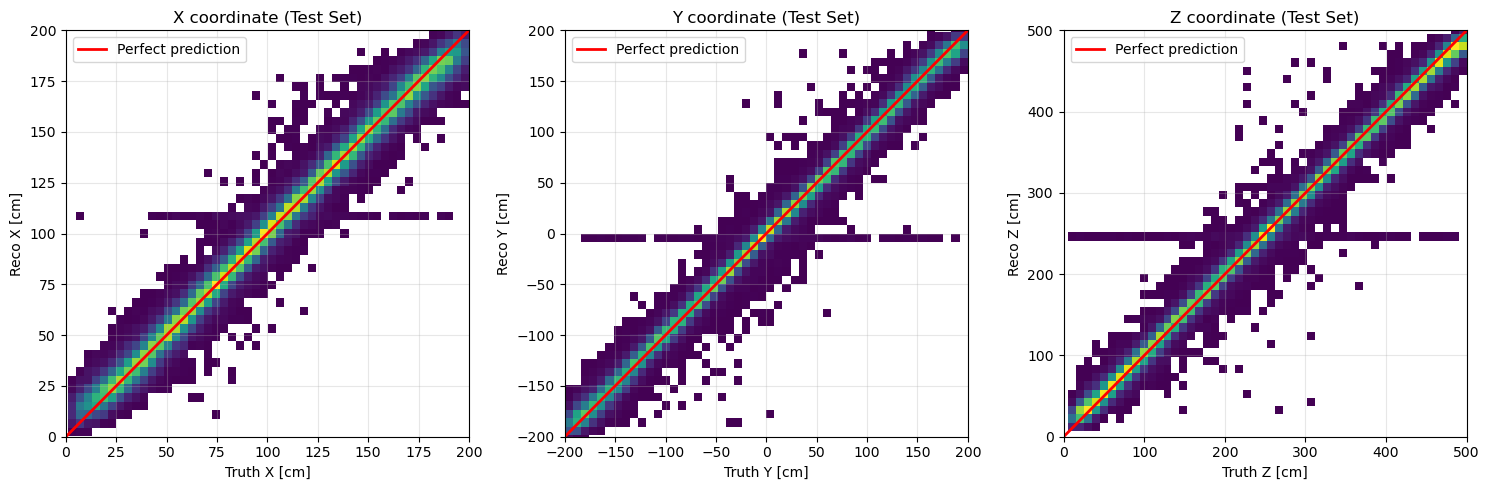

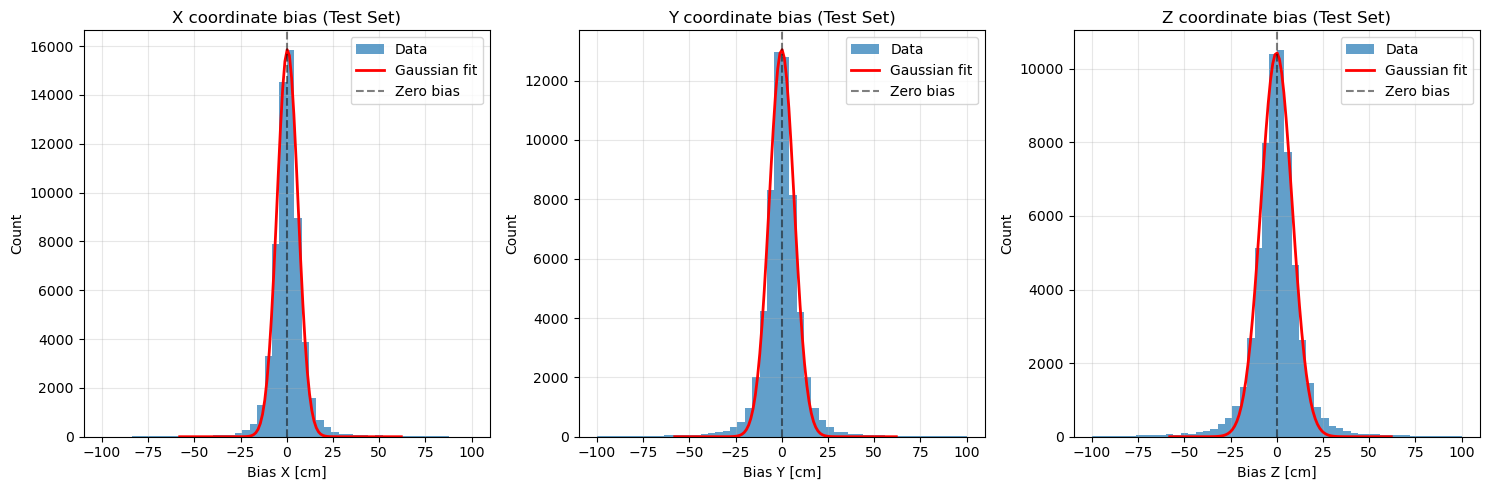


>> Test Set Bias Analysis Results:
* X coordinate:
  - Mean bias: 0.38 cm
  - Resolution (σ): 5.67 cm

* Y coordinate:
  - Mean bias: -0.06 cm
  - Resolution (σ): 6.76 cm

* Z coordinate:
  - Mean bias: -0.16 cm
  - Resolution (σ): 8.47 cm



In [ ]:
# Advanced Analysis Plots - Reco vs Truth and Bias Analysis
if has_inference_tree and len(passed_events) > 0:
    from scipy.optimize import curve_fit
    
    valid_predictions = passed_events[passed_events['error_3d'] != -999.0]
    
    if len(valid_predictions) > 0:
        # Extract truth and predicted coordinates
        y_test_original = np.column_stack([
            valid_predictions['true_x'].values,
            valid_predictions['true_y'].values, 
            valid_predictions['true_z'].values
        ])
        
        y_pred_original = np.column_stack([
            valid_predictions['pred_x'].values,
            valid_predictions['pred_y'].values,
            valid_predictions['pred_z'].values
        ])
        
        # Configuration for plots
        ANALYSIS_CONFIG = {
            'reco_truth_comparison': {
                'bins': 50,
                'cmap': 'viridis'
            },
            'bias_analysis': {
                'hist_bins': 50,
                'hist_ranges': {
                    'X': (-100, 100),
                    'Y': (-100, 100), 
                    'Z': (-100, 100)
                },
                'fit_ranges': {
                    'X': (10, 40),
                    'Y': (10, 40),
                    'Z': (10, 40)
                }
            }
        }
        
        # Reco vs Truth comparison plots
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        coord_names = ['X', 'Y', 'Z']
        coord_limits = [(0, 200), (-200, 200), (0, 500)]

        for i, (coord, limits) in enumerate(zip(coord_names, coord_limits)):
            hist, xedges, yedges = np.histogram2d(
                y_test_original[:, i],
                y_pred_original[:, i],
                bins=ANALYSIS_CONFIG['reco_truth_comparison']['bins']
            )
            
            hist_masked = np.ma.masked_where(hist <= 2, hist)
            
            im = axs[i].pcolormesh(
                xedges, yedges, hist_masked.T,
                cmap=ANALYSIS_CONFIG['reco_truth_comparison']['cmap'],
                shading='auto'
            )
            
            axs[i].plot(limits, limits, 'r-', linewidth=2, label='Perfect prediction')
            axs[i].set_xlim(limits)
            axs[i].set_ylim(limits)
            axs[i].set_xlabel(f'Truth {coord} [cm]')
            axs[i].set_ylabel(f'Reco {coord} [cm]')
            axs[i].set_title(f'{coord} coordinate (Test Set)')
            axs[i].grid(True, alpha=0.3)
            axs[i].legend()

        plt.tight_layout()
        plt.show()
        
        # Calculate differences (bias)
        diff_coords = y_pred_original - y_test_original

        # Gaussian fit function
        def gaussian(x, a, x0, sigma):
            return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

        # Bias analysis plots
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        bias_results = {}

        for i, coord in enumerate(coord_names):
            diff = diff_coords[:, i]
            config = ANALYSIS_CONFIG['bias_analysis']
            
            # Create histogram
            counts, bins, _ = axs[i].hist(
                diff, 
                config['hist_bins'], 
                range=config['hist_ranges'][coord],
                alpha=0.7,
                label='Data'
            )
            
            # Prepare for Gaussian fit
            bin_centers = (bins[:-1] + bins[1:]) / 2
            fit_range = config['fit_ranges'][coord]
            
            # Fit Gaussian
            try:
                p0 = [np.max(counts), 0, 50]
                popt, _ = curve_fit(
                    gaussian, 
                    bin_centers[fit_range[0]:fit_range[1]], 
                    counts[fit_range[0]:fit_range[1]], 
                    p0=p0
                )
                
                # Plot fit
                x_fit = np.linspace(bin_centers[fit_range[0]], bin_centers[fit_range[1]], 100)
                y_fit = gaussian(x_fit, *popt)
                axs[i].plot(x_fit, y_fit, 'r-', linewidth=2, label='Gaussian fit')
                
                # Store results
                bias_results[coord] = {
                    'mean': popt[1],
                    'sigma': popt[2]
                }
                
            except Exception as e:
                print(f"! Warning: Could not fit Gaussian for {coord}: {e}")
                bias_results[coord] = {
                    'mean': np.mean(diff),
                    'sigma': np.std(diff)
                }
            
            axs[i].axvline(0, color='black', linestyle='--', alpha=0.5, label='Zero bias')
            axs[i].set_xlabel(f'Bias {coord} [cm]')
            axs[i].set_ylabel('Count')
            axs[i].set_title(f'{coord} coordinate bias (Test Set)')
            axs[i].legend()
            axs[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print bias results
        print("\n>> Test Set Bias Analysis Results:")
        print("=" * 40)
        for coord in coord_names:
            mean = bias_results[coord]['mean']
            sigma = bias_results[coord]['sigma']
            print(f"* {coord} coordinate:")
            print(f"  - Mean bias: {mean:.2f} cm")
            print(f"  - Resolution (σ): {sigma:.2f} cm")
            print()
    
    else:
        print("No valid predictions available for advanced plotting.")
else:
    print("TTree data not available or no events passed filters.")

### Read pixelmap

In [185]:
# ==============================================================================
# LOAD PIXELMAP DATA - AUTO-DETECTING BRANCH NAME
# ==============================================================================

file_path = "/exp/sbnd/app/users/svidales/larsoft_develop/run_try/2010/pixelmap_variables_PosRecoCVNProd-20251020T163726.root"
MAX_EVENTS_TO_LOAD = 200  # Adjust as needed

print("=" * 80)
print("📂 LOADING PIXELMAP DATA")
print("=" * 80)
print(f"File: {file_path}")
print(f"File exists: {Path(file_path).exists()}")

if not Path(file_path).exists():
    print("❌ File not found!")
else:
    # Open file
    file = uproot.open(file_path)
    events_tree = file['Events;1']
    print(f"✅ Events tree found with {events_tree.num_entries} entries")

    # Auto-detect correct branch name
    print("\n🔍 Auto-detecting PixelMapVars branch...")
    pixelmap_branch = None
    for key in events_tree.keys():
        if 'PixelMapVars' in key and '.obj' in key:
            pixelmap_branch = key
            print(f"✅ Found PixelMapVars branch: {pixelmap_branch}")
            break

    if not pixelmap_branch:
        print("❌ No PixelMapVars branch found in file!")
        print("Available branches:")
        for key in list(events_tree.keys())[:10]:
            print(f"  - {key}")
    else:
        # Load events
        events_data = []
        max_events = min(MAX_EVENTS_TO_LOAD, events_tree.num_entries)

        print(f"\n📥 Loading first {max_events} events...")
        try:
            pixelmap_arrays = events_tree[pixelmap_branch].array(entry_stop=max_events, library='np')
            print(f"✅ Loaded {len(pixelmap_arrays)} PixelMapVars objects")

            # Process each event
            for i in range(len(pixelmap_arrays)):
                try:
                    pixelmap_obj = pixelmap_arrays[i]

                    event_data = {
                        'event_index': i,
                        'pe_images': None,
                        'physics': {}
                    }

                    # Access PE images using tolist() method
                    try:
                        pe_images_stl = pixelmap_obj.member('pe_images')

                        if len(pe_images_stl) > 0:
                            # Convert STLVector to list, then to numpy array
                            pe_images_list = pe_images_stl.tolist()
                            pe_images_data = np.array(pe_images_list)

                            if pe_images_data.size > 0:
                                # Handle different possible shapes
                                if len(pe_images_data.shape) == 4 and pe_images_data.shape[0] == 1:
                                    pe_data = pe_images_data[0]  # Remove first dim
                                    event_data['pe_images'] = pe_data
                                elif len(pe_images_data.shape) == 3:
                                    event_data['pe_images'] = pe_images_data
                                else:
                                    event_data['pe_images'] = pe_images_data

                    except Exception as e:
                        if i < 3:
                            print(f"  Event {i}: Error with pe_images: {e}")

                    # Extract physics variables
                    physics_vars = ['dEpromx', 'dEpromy', 'dEpromz', 'dEtpc',
                                   'run_id', 'subrun_id', 'event_id']
                    for var in physics_vars:
                        try:
                            stl_vec = pixelmap_obj.member(var)
                            if len(stl_vec) > 0:
                                values_list = stl_vec.tolist()
                                if len(values_list) > 0:
                                    event_data['physics'][var] = values_list[0]
                        except:
                            pass

                    # Set event ID if not found
                    if 'event_id' not in event_data['physics']:
                        event_data['physics']['event_id'] = i

                    # Only keep events with valid PE images
                    if event_data['pe_images'] is not None and event_data['pe_images'].size > 0:
                        events_data.append(event_data)

                except Exception as e:
                    if i < 5:
                        print(f"  Event {i}: Processing error: {e}")
                    continue

            print(f"\n✅ Successfully loaded {len(events_data)} events with PE images")

            if len(events_data) > 0:
                # Show sample event structure
                sample_event = events_data[0]
                print(f"\n📊 Sample event structure (index {sample_event['event_index']}):")
                if sample_event['pe_images'] is not None:
                    print(f"  PE images shape: {sample_event['pe_images'].shape}")
                    print(f"  PE images dtype: {sample_event['pe_images'].dtype}")
                    print(f"  Non-zero pixels: {np.count_nonzero(sample_event['pe_images'])}")
                    if np.count_nonzero(sample_event['pe_images']) > 0:
                        print(f"  PE range: {sample_event['pe_images'].min():.6f} - {sample_event['pe_images'].max():.6f}")

                print(f"  Physics keys: {list(sample_event['physics'].keys())}")
                for key, value in sample_event['physics'].items():
                    if isinstance(value, float):
                        print(f"    {key}: {value:.2f}")
                    else:
                        print(f"    {key}: {value}")

                # Statistics
                pe_counts = [np.count_nonzero(event['pe_images']) for event in events_data]
                energies = [event['physics'].get('dEtpc', 0) for event in events_data]

                print(f"\n📈 Dataset Statistics:")
                print(f"  Events with PE data: {len(events_data)}")
                print(f"  PE pixels range: {min(pe_counts)} - {max(pe_counts)}")
                print(f"  Energy range: {min(energies):.1f} - {max(energies):.1f} MeV")
                print(f"  Events with >50 PE pixels: {sum(1 for pe in pe_counts if pe > 50)}")

                # Show first 15 events
                print(f"\n🎯 First 15 events available:")
                print(f"{'Index':<8} {'Event ID':<10} {'Energy (MeV)':<15} {'PE pixels':<10}")
                print("-" * 50)
                for i, event in enumerate(events_data[:15]):
                    event_id = event['physics'].get('event_id', i)
                    energy = event['physics'].get('dEtpc', -999)
                    pe_count = np.count_nonzero(event['pe_images'])
                    print(f"{i:<8} {event_id:<10} {energy:<15.1f} {pe_count:<10}")

                if len(events_data) > 15:
                    print(f"... and {len(events_data) - 15} more events")

            else:
                print("❌ No events with valid PE images found")

        except Exception as e:
            print(f"❌ Error loading pixelmap data: {e}")
            import traceback
            traceback.print_exc()

print("\n" + "=" * 80)

📂 LOADING PIXELMAP DATA
File: /exp/sbnd/app/users/svidales/larsoft_develop/run_try/2010/pixelmap_variables_PosRecoCVNProd-20251020T163726.root
File exists: True
✅ Events tree found with 66 entries

🔍 Auto-detecting PixelMapVars branch...
✅ Found PixelMapVars branch: PixelMapVars_opanatree__PosRecoCVNProd./PixelMapVars_opanatree__PosRecoCVNProd.obj

📥 Loading first 66 events...
✅ Loaded 66 PixelMapVars objects

✅ Successfully loaded 16 events with PE images

📊 Sample event structure (index 7):
  PE images shape: (59, 70, 2)
  PE images dtype: float32
  Non-zero pixels: 46
  PE range: 0.000000 - 0.206216
  Physics keys: ['dEpromx', 'dEpromy', 'dEpromz', 'dEtpc', 'event_id']
    dEpromx: 168.75
    dEpromy: -41.88
    dEpromz: 151.97
    dEtpc: 575.88
    event_id: 7

📈 Dataset Statistics:
  Events with PE data: 16
  PE pixels range: 45 - 49
  Energy range: 198.0 - 1544.8 MeV
  Events with >50 PE pixels: 0

🎯 First 15 events available:
Index    Event ID   Energy (MeV)    PE pixels 
------

In [ ]:
# ==============================================================================
# VISUALIZATION FUNCTION
# ==============================================================================

def visualize_chosen_event(events_data, chosen_index):
    """
    Visualize PE images for a chosen event with comprehensive information display.

    Parameters:
    -----------
    events_data : list
        List of event dictionaries containing 'pe_images' and 'physics' data
    chosen_index : int
        Index in the events_data list (NOT event_id!)
    """
    # Validate input
    if not events_data:
        print("❌ No events loaded! Please run the data loading cell first.")
        return

    if chosen_index < 0 or chosen_index >= len(events_data):
        print(f"❌ Invalid index {chosen_index}! Must be between 0 and {len(events_data)-1}")
        print(f"\n💡 Available events (showing first 15):")
        print(f"{'Index':<8} {'Event ID':<10} {'Energy (MeV)':<15} {'PE pixels':<10}")
        print("-" * 50)
        for i, event in enumerate(events_data[:15]):
            event_id = event['physics'].get('event_id', i)
            energy = event['physics'].get('dEtpc', -999)
            pe_count = np.count_nonzero(event['pe_images'])
            print(f"{i:<8} {event_id:<10} {energy:<15.1f} {pe_count:<10}")
        if len(events_data) > 15:
            print(f"... and {len(events_data) - 15} more events")
        return

    # Get the event
    event = events_data[chosen_index]
    pe_images = event['pe_images']
    physics = event['physics']

    # Validate PE images
    if pe_images is None or pe_images.size == 0:
        print(f"❌ Event {chosen_index} has no PE image data!")
        return

    # Print event information
    print("=" * 80)
    print(f"📊 EVENT VISUALIZATION - Index {chosen_index}")
    print("=" * 80)

    print(f"\n🔢 Event Information:")
    print(f"  List Index: {chosen_index}")
    print(f"  Event ID: {physics.get('event_id', 'N/A')}")
    print(f"  Run/Subrun/Event: {physics.get('run_id', 'N/A')}/{physics.get('subrun_id', 'N/A')}/{physics.get('event_id', 'N/A')}")

    print(f"\n⚡ Physics Variables:")
    print(f"  Energy (dEtpc): {physics.get('dEtpc', -999):.2f} MeV")
    print(f"  Prompt X: {physics.get('dEpromx', -999):.2f}")
    print(f"  Prompt Y: {physics.get('dEpromy', -999):.2f}")
    print(f"  Prompt Z: {physics.get('dEpromz', -999):.2f}")

    print(f"\n🖼️  PE Image Shape: {pe_images.shape}")
    print(f"  Expected format: (height, width, 2) where 2 = [uncoated, coated]")
    
    # Determine TPC from dEpromx (if available)
    tpc_label = "Unknown TPC"
    dEpromx = physics.get('dEpromx', None)
    if dEpromx is not None and dEpromx != -999:
        if dEpromx < 0:
            tpc_label = "TPC0 (x<0, even PMTs)"
        else:
            tpc_label = "TPC1 (x>0, odd PMTs)"
        print(f"  ✅ TPC identified from dEpromx={dEpromx:.2f}: {tpc_label}")
    else:
        print(f"  ⚠️  TPC cannot be determined (no dEpromx available)")
        print(f"     Note: Code selects TPC half automatically based on max signal")

    # Determine image structure
    if len(pe_images.shape) == 3 and pe_images.shape[2] == 2:
        uncoated = pe_images[:, :, 0]
        coated = pe_images[:, :, 1]
        print(f"  ✅ Correctly structured PE images detected")
    elif len(pe_images.shape) == 3 and pe_images.shape[0] == 2:
        uncoated = pe_images[0, :, :]
        coated = pe_images[1, :, :]
        print(f"  ⚠️  Alternative structure (2, height, width) - transposing")
    elif len(pe_images.shape) == 2:
        print(f"  ⚠️  2D array - assuming single PMT type")
        uncoated = pe_images
        coated = np.zeros_like(pe_images)
    else:
        print(f"  ❌ Unexpected PE image shape: {pe_images.shape}")
        return

    # Statistics
    uncoated_nonzero = np.count_nonzero(uncoated)
    coated_nonzero = np.count_nonzero(coated)
    total_nonzero = uncoated_nonzero + coated_nonzero

    print(f"\n📈 PE Statistics:")
    print(f"  Uncoated PMT hits: {uncoated_nonzero}")
    if uncoated_nonzero > 0:
        print(f"    PE range: {uncoated.min():.6f} - {uncoated.max():.6f}")
        print(f"    Mean PE (non-zero): {uncoated[uncoated > 0].mean():.6f}")

    print(f"  Coated PMT hits: {coated_nonzero}")
    if coated_nonzero > 0:
        print(f"    PE range: {coated.min():.6f} - {coated.max():.6f}")
        print(f"    Mean PE (non-zero): {coated[coated > 0].mean():.6f}")

    print(f"  Total hits: {total_nonzero}")

    # Create custom colormap with light gray background for zero values
    from matplotlib.colors import LinearSegmentedColormap
    
    # Create colormap: light gray -> viridis colors
    viridis = plt.cm.get_cmap('viridis')
    colors = [(0.95, 0.95, 0.95, 1)]  # Start with very light gray (not pure white)
    # Add viridis colors
    for i in range(256):
        colors.append(viridis(i))
    
    custom_cmap = LinearSegmentedColormap.from_list('lightgray_viridis', colors, N=257)
    
    # Create visualization with white background
    fig, axes = plt.subplots(1, 2, figsize=(20,9), dpi=300, facecolor='white')

    # Uncoated PMTs (left)
    im1 = axes[0].imshow(uncoated, cmap=custom_cmap, aspect='auto', interpolation='nearest', 
                         vmin=0, vmax=uncoated.max() if uncoated.max() > 0 else 1)
    axes[0].set_title(f'Uncoated PMTs\n{uncoated_nonzero} hits',
                      fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel('Z (columns)', fontsize=12)
    axes[0].set_ylabel('Y (rows)', fontsize=12)
    axes[0].set_facecolor('white')
    # Add border to the image
    for spine in axes[0].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    # Turn off grid
    axes[0].grid(False)
    plt.colorbar(im1, ax=axes[0], label='PE (photoelectrons)')

    # Coated PMTs (right)
    im2 = axes[1].imshow(coated, cmap=custom_cmap, aspect='auto', interpolation='nearest',
                         vmin=0, vmax=coated.max() if coated.max() > 0 else 1)
    axes[1].set_title(f'Coated PMTs\n{coated_nonzero} hits',
                      fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel('Z (columns)', fontsize=12)
    axes[1].set_ylabel('Y (rows)', fontsize=12)
    axes[1].set_facecolor('white')
    # Add border to the image
    for spine in axes[1].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    # Turn off grid
    axes[1].grid(False)
    plt.colorbar(im2, ax=axes[1], label='PE (photoelectrons)')

    # Overall title with TPC info
    title_text = f'Event {chosen_index}'
    if dEpromx is not None and dEpromx != -999:
        title_text += f' - {tpc_label}'
    title_text += f' - Energy: {physics.get("dEtpc", -999):.1f} MeV'
    
    fig.suptitle(title_text, fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    print("\n" + "=" * 80)

print("✅ Visualization function loaded successfully!")

📊 EVENT VISUALIZATION - Index 11

🔢 Event Information:
  List Index: 11
  Event ID: 51
  Run/Subrun/Event: N/A/N/A/51

⚡ Physics Variables:
  Energy (dEtpc): 1544.78 MeV
  Prompt X: 140.33
  Prompt Y: 119.58
  Prompt Z: 110.01

🖼️  PE Image Shape: (59, 70, 2)
  Expected format: (height, width, 2) where 2 = [uncoated, coated]
  ✅ TPC identified from dEpromx=140.33: TPC1 (x>0, odd PMTs)
  ✅ Correctly structured PE images detected

📈 PE Statistics:
  Uncoated PMT hits: 9
    PE range: 0.000000 - 0.030024
    Mean PE (non-zero): 0.019057
  Coated PMT hits: 36
    PE range: 0.000000 - 0.404930
    Mean PE (non-zero): 0.093109
  Total hits: 45


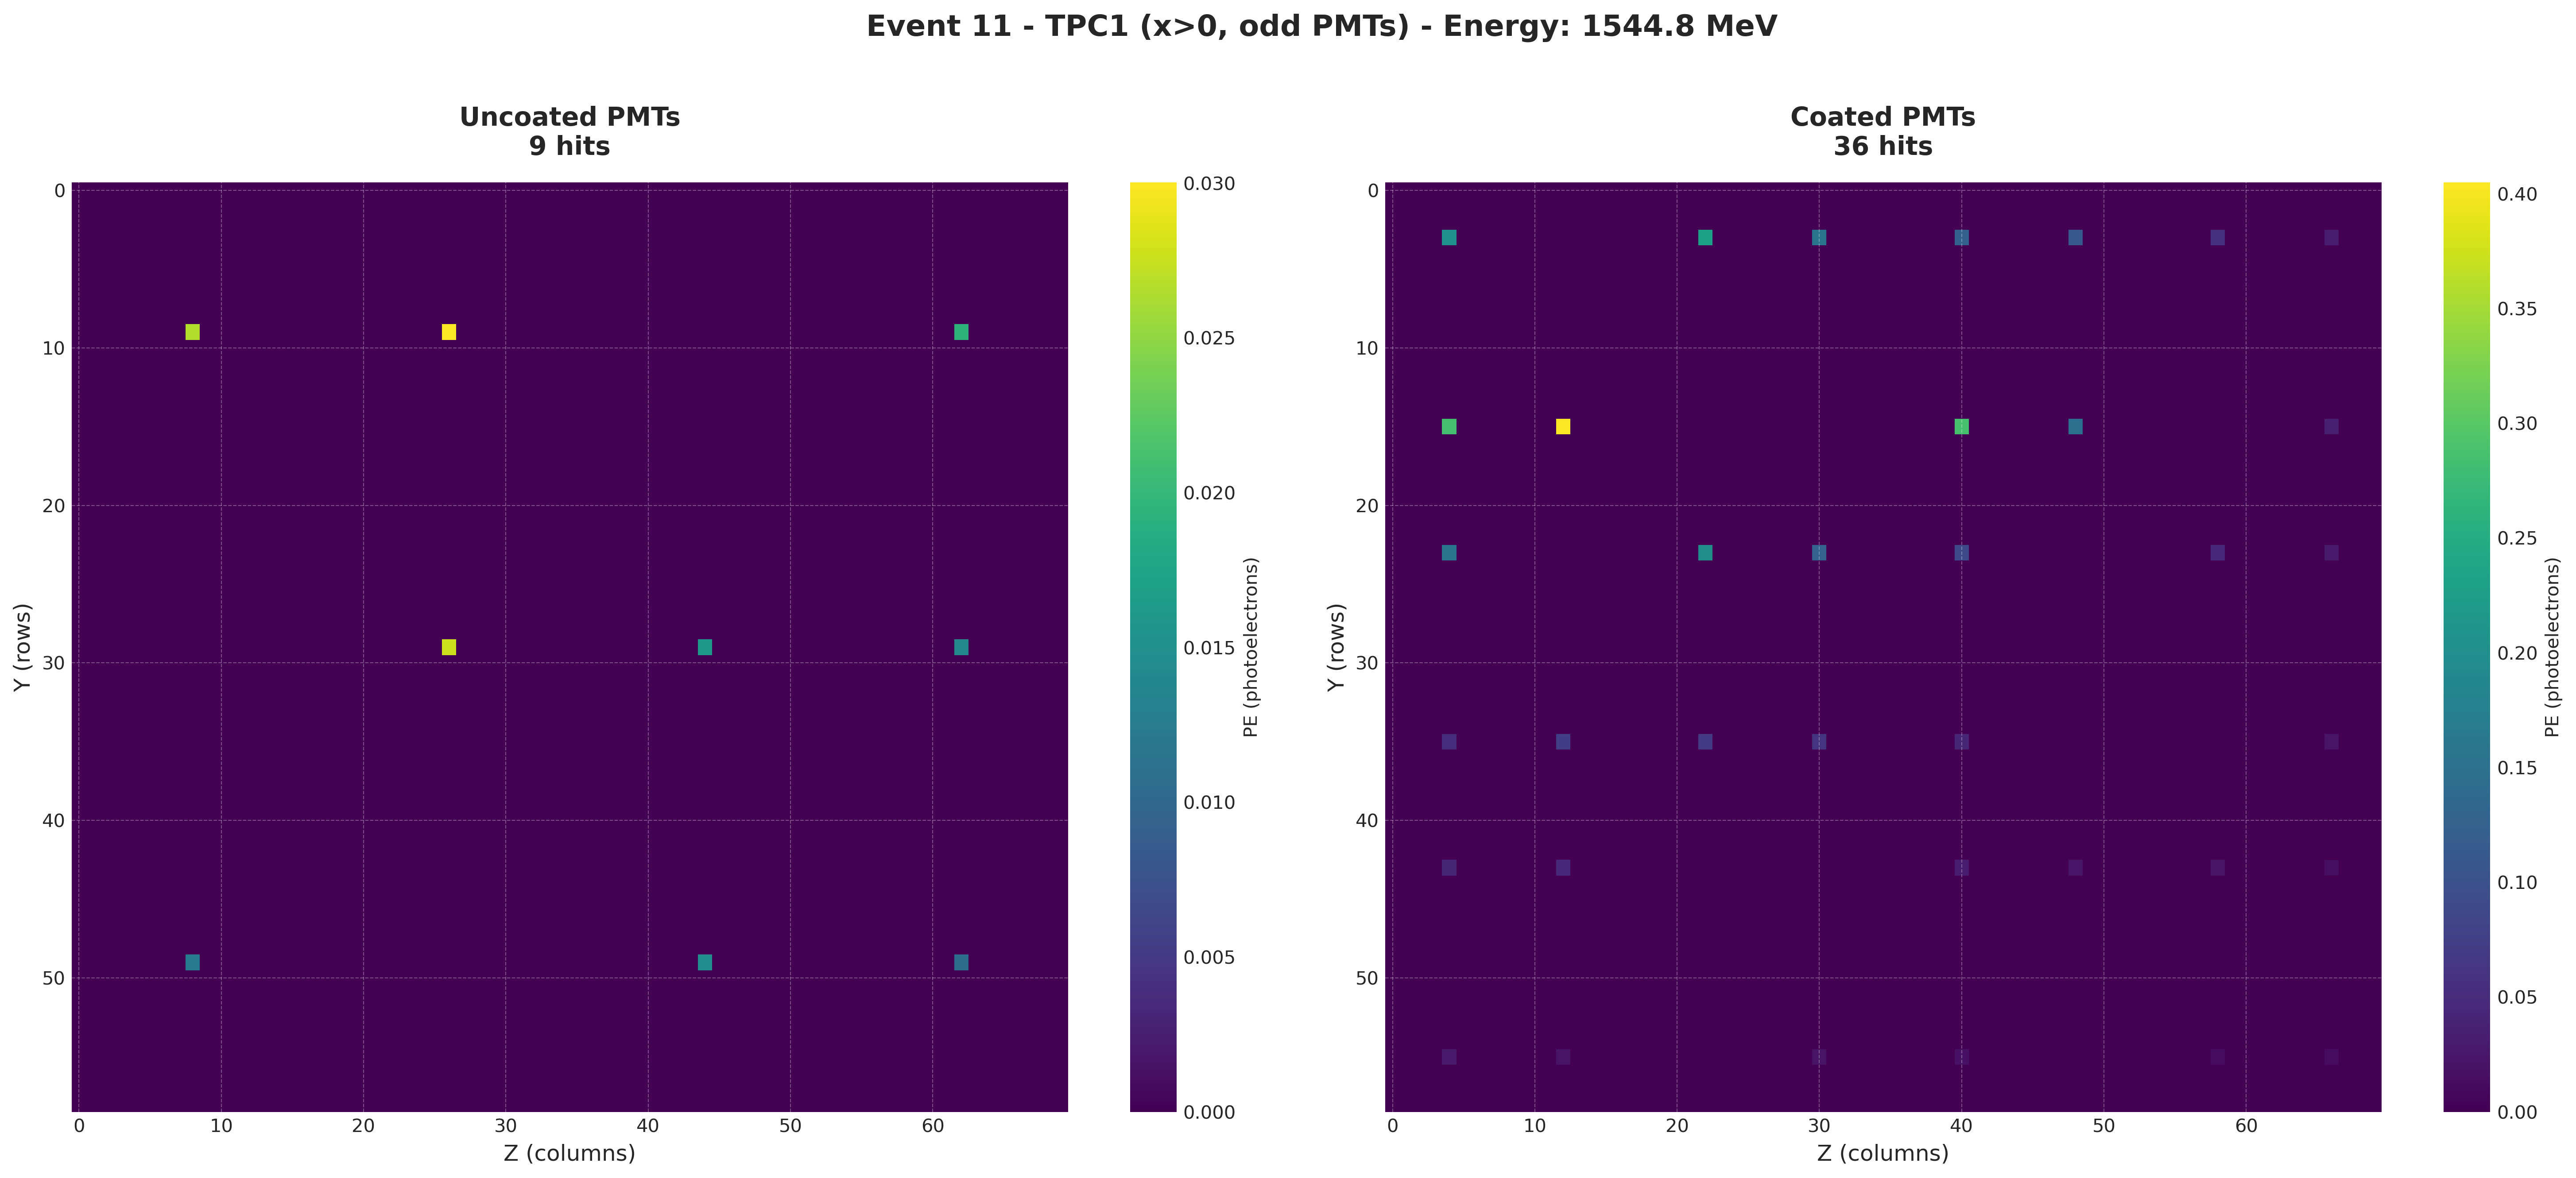

In [197]:
# ==============================================================================
# VISUALIZE AN EVENT
# ==============================================================================

# Choose the event INDEX you want to visualize
# IMPORTANT: Use the INDEX (0, 1, 2, ...), NOT the event_id!
# See the event list printed above to choose an interesting event

CHOSEN_EVENT_INDEX = 11  # Change this to any index from the events list above

# Visualize the chosen event
visualize_chosen_event(events_data, chosen_index=CHOSEN_EVENT_INDEX)

# To see the list of available events again, use a negative index:
# visualize_chosen_event(events_data, chosen_index=-1)